In [25]:
import os
import json
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

In [26]:
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():  # for GPU
    torch.cuda.manual_seed_all(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [27]:
##### read model-ready data
X_train = np.load("X_train.npy")
Y_train = np.load("y_train.npy")
X_test = np.load("X_test.npy")
Y_test = np.load("y_test.npy")

# if Y is loaded as flat list, convert into column format (for the model to undersatnd)
if Y_train.ndim == 1:
    Y_train = Y_train.reshape(-1, 1)
if Y_test.ndim == 1:
    Y_test = Y_test.reshape(-1, 1)

print("X_train:", X_train.shape)
print("Y_train:", Y_train.shape)
print("X_test:", X_test.shape)
print("Y_test:", Y_test.shape)

X_train: (57420, 24, 1)
Y_train: (57420, 1)
X_test: (14356, 24, 1)
Y_test: (14356, 1)


In [28]:
##### splitting data for training and validation
val_ratio = 0.2  # use 20% data for validation and 80% for training
val_size = int(len(X_train) * val_ratio)

X_train_2 = X_train[:-val_size]
Y_train_2 = Y_train[:-val_size]
X_val = X_train[-val_size:]
Y_val = Y_train[-val_size:]

print("Train:", X_train_2.shape, Y_train_2.shape)
print("Val:", X_val.shape, Y_val.shape)

Train: (45936, 24, 1) (45936, 1)
Val: (11484, 24, 1) (11484, 1)


In [29]:
##### dataset and dataloader
# convert numpy arrays to torch tensors
X_train_tensor = torch.tensor(X_train_2, dtype=torch.float32)
Y_train_tensor = torch.tensor(Y_train_2, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
Y_val_tensor = torch.tensor(Y_val, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
Y_test_tensor = torch.tensor(Y_test, dtype=torch.float32)

# create dataloaders
train_loader = DataLoader(list(zip(X_train_tensor, Y_train_tensor)), batch_size=128, shuffle=True)
val_loader = DataLoader(list(zip(X_val_tensor, Y_val_tensor)), batch_size=128, shuffle=False)
test_loader = DataLoader(list(zip(X_test_tensor, Y_test_tensor)), batch_size=128, shuffle=False)

In [30]:
##### LSTM regressor
class LSTMRegressor(nn.Module):
    def __init__(self, input_size, hidden_size, dropout):
        super().__init__()
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size, batch_first=True)
        self.drop = nn.Dropout(dropout)
        self.fc1 = nn.Linear(hidden_size, 32)
        self.fc2 = nn.Linear(32, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        # x: (batch, timesteps, features)
        out, _ = self.lstm(x) # out: (batch, timesteps, hidden)
        out = out[:, -1, :] # last timestep: (batch, hidden)
        out = self.drop(out)
        out = self.relu(self.fc1(out))
        out = self.fc2(out) # (batch, 1)
        return out

In [31]:
##### 1D CNN regressors
class CNN1DRegressor(nn.Module):
    def __init__(self, in_channels, dropout):
        super().__init__()
        self.conv1 = nn.Conv1d(in_channels=in_channels, out_channels=64, kernel_size=3, padding=2)
        self.conv2 = nn.Conv1d(in_channels=64, out_channels=64, kernel_size=3, padding=2)
        self.pool = nn.MaxPool1d(kernel_size=2)
        self.drop = nn.Dropout(dropout)
        self.relu = nn.ReLU()

        # infer flatten size using a dummy forward
        self._fc1 = None
        self.fc2 = nn.Linear(32, 1)

    def _build_fc(self, x_shape):
        # x: (batch, timesteps, features) -> becomes (batch, features, timesteps)
        with torch.no_grad():
            dummy = torch.zeros(x_shape, dtype=torch.float32)
            dummy = dummy.permute(0, 2, 1)  # (B, F, T)
            z = self.pool(self.relu(self.conv1(dummy)))
            z = self.pool(self.relu(self.conv2(z)))
            z = torch.flatten(z, start_dim=1)
            self._fc1 = nn.Linear(z.shape[1], 32)

    def forward(self, x):
        # x: (batch, timesteps, features)
        x = x.permute(0, 2, 1)  # (B, F, T)
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = self.drop(x)
        x = torch.flatten(x, start_dim=1)
        x = self.relu(self._fc1(x))
        x = self.fc2(x)
        return x

In [32]:
##### metrics helper functions
# mean absolute error
def mae(pred, target):
    return torch.mean(torch.abs(pred - target))

# root mean squared error
def rmse(pred, target):
    return torch.sqrt(torch.mean((pred-target)**2))

In [33]:
##### model training function
def train_model(model, model_name, train_loader, val_loader, epochs=30, lr=1e-3):
    model.to(device)
    criterion = nn.MSELoss()  # training error for regression
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)  # update weights to reduce error

    history = {
        "train_loss": [], "val_loss": [],
        "train_mae": [],  "val_mae": [],
        "train_rmse": [], "val_rmse": []
    }

    best_val_loss = float("inf")
    best_path = f"best_{model_name}.pt"

    for epoch in range(1, epochs + 1):
        # training-
        model.train()
        train_losses, train_maes, train_rmses = [], [], []
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)

            optimizer.zero_grad()
            preds = model(xb)
            loss = criterion(preds, yb)
            loss.backward()
            optimizer.step()

            train_losses.append(loss.item())
            train_maes.append(mae(preds, yb).item())
            train_rmses.append(rmse(preds, yb).item())

        # validate-
        model.eval()
        val_losses, val_maes, val_rmses = [], [], []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                preds = model(xb)
                loss = criterion(preds, yb)

                val_losses.append(loss.item())
                val_maes.append(mae(preds, yb).item())
                val_rmses.append(rmse(preds, yb).item())

        train_loss = float(np.mean(train_losses))
        val_loss = float(np.mean(val_losses))
        train_mae = float(np.mean(train_maes))
        val_mae = float(np.mean(val_maes))
        train_rmse = float(np.mean(train_rmses))
        val_rmse = float(np.mean(val_rmses))

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_mae"].append(train_mae)
        history["val_mae"].append(val_mae)
        history["train_rmse"].append(train_rmse)
        history["val_rmse"].append(val_rmse)

        # save best model but training keep runnning
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), best_path)
            best_saved = "BEST SAVED!!!"
        else:
            best_saved = ""

        print(
            f"Epoch [{epoch}/{epochs}] "
            f"TrainLoss: {train_loss:.6f} ValLoss: {val_loss:.6f} | "
            f"TrainMAE: {train_mae:.6f} ValMAE: {val_mae:.6f} | "
            f"TrainRMSE: {train_rmse:.6f} ValRMSE: {val_rmse:.6f} {best_saved}"
        )

    # save history
    with open(f"history_{model_name}.json", "w") as f:
        json.dump(history, f, indent=2)

    print(f"\nSaved: {best_path}, history_{model_name}.json")
    return history

In [34]:
##### building and training both models (LSTM and CNN)
timesteps = X_train_2.shape[1]
features = X_train_2.shape[2]

lstm = LSTMRegressor(input_size=features, hidden_size=64, dropout=0.2)
cnn = CNN1DRegressor(in_channels=features, dropout=0.2)
cnn._build_fc((1, timesteps, features))  # initialize fc1 based on input shape

EPOCHS = 30
print("\nTraining LSTM model")
hist_lstm = train_model(lstm, "LSTM", train_loader, val_loader, epochs=EPOCHS, lr=1e-3)
print("\nTraining CNN model")
hist_cnn = train_model(cnn, "CNN", train_loader, val_loader, epochs=EPOCHS, lr=1e-3)


Training LSTM model
Epoch [1/30] TrainLoss: 0.086603 ValLoss: 0.007025 | TrainMAE: 0.154941 ValMAE: 0.060896 | TrainRMSE: 0.209389 ValRMSE: 0.079039 BEST SAVED!!!
Epoch [2/30] TrainLoss: 0.011155 ValLoss: 0.003679 | TrainMAE: 0.071506 ValMAE: 0.043364 | TrainRMSE: 0.099740 ValRMSE: 0.056826 BEST SAVED!!!
Epoch [3/30] TrainLoss: 0.009252 ValLoss: 0.003465 | TrainMAE: 0.062983 ValMAE: 0.042416 | TrainRMSE: 0.089423 ValRMSE: 0.055212 BEST SAVED!!!
Epoch [4/30] TrainLoss: 0.008560 ValLoss: 0.002668 | TrainMAE: 0.059705 ValMAE: 0.036359 | TrainRMSE: 0.085293 ValRMSE: 0.048102 BEST SAVED!!!
Epoch [5/30] TrainLoss: 0.007761 ValLoss: 0.002334 | TrainMAE: 0.056764 ValMAE: 0.032839 | TrainRMSE: 0.081100 ValRMSE: 0.044340 BEST SAVED!!!
Epoch [6/30] TrainLoss: 0.007661 ValLoss: 0.002400 | TrainMAE: 0.056212 ValMAE: 0.033714 | TrainRMSE: 0.080529 ValRMSE: 0.045180 
Epoch [7/30] TrainLoss: 0.007340 ValLoss: 0.002182 | TrainMAE: 0.054145 ValMAE: 0.031306 | TrainRMSE: 0.077906 ValRMSE: 0.042740 BEST 

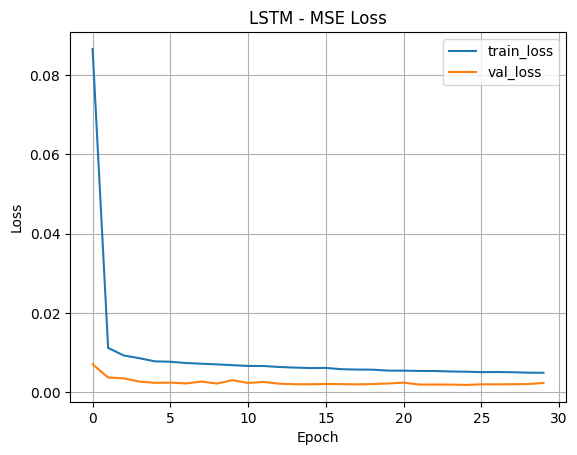

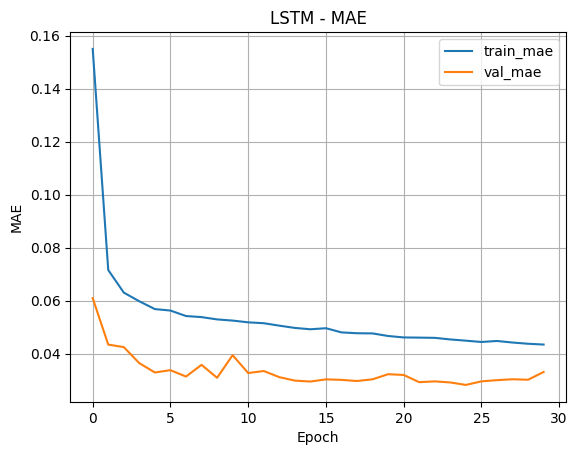

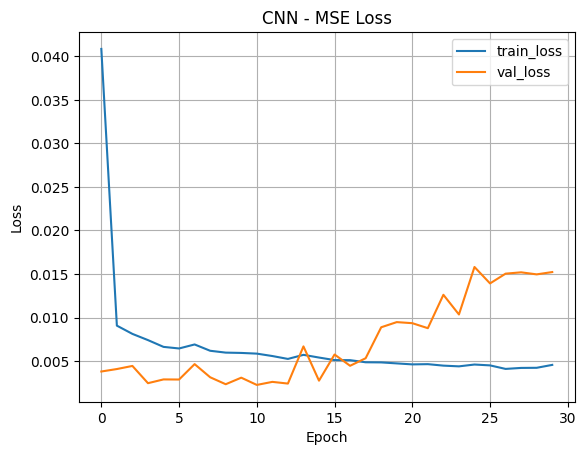

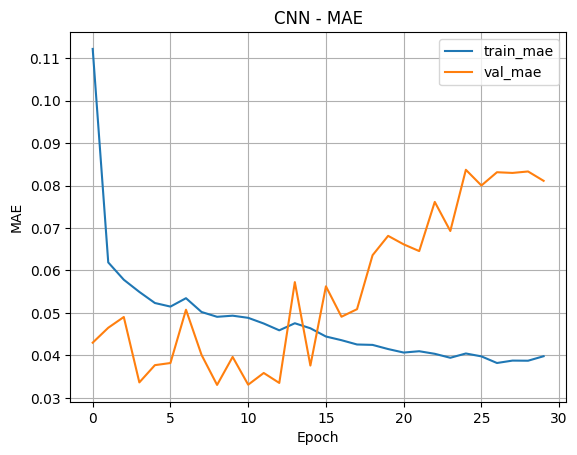

In [35]:
##### plot training curves
def plot_curves(hist, title_prefix):
    # loss
    plt.figure()
    plt.plot(hist["train_loss"], label="train_loss")
    plt.plot(hist["val_loss"], label="val_loss")
    plt.title(f"{title_prefix} - MSE Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.legend()
    plt.show()

    # mae
    plt.figure()
    plt.plot(hist["train_mae"], label="train_mae")
    plt.plot(hist["val_mae"], label="val_mae")
    plt.title(f"{title_prefix} - MAE")
    plt.xlabel("Epoch")
    plt.ylabel("MAE")
    plt.grid(True)
    plt.legend()
    plt.show()

plot_curves(hist_lstm, "LSTM")
plot_curves(hist_cnn, "CNN")